<a href="https://colab.research.google.com/github/FirstTheKing05/Webtech67/blob/main/week12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install ultralytics gdown
import ultralytics, torch
ultralytics.checks()
print('มีการ์ดจอให้ใช้ไหม', torch.cuda.is_available())


Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.7/107.7 GB disk)
มีการ์ดจอให้ใช้ไหม False


In [2]:
import os, glob
ROOT = '/content/lpr'
FILE_ID = '1-ZXdR3FtlZn_u1Mqf9qJ3pOnhYEgurAt'      # รหัสของ lpr-week12-data.zip บน Google Drive ของอาจารย์
if not os.path.exists(f'{ROOT}/gate'):
    !gdown {FILE_ID} -O /content/lpr-week12-data.zip
    !unzip -q /content/lpr-week12-data.zip -d {ROOT}
for s in ['train', 'val', 'test']:
    print(f'gate/{s}', len(glob.glob(f'{ROOT}/gate/{s}/images/*')), 'ภาพ')
print('road', len(glob.glob(f'{ROOT}/road/images/*')), 'เฟรม')
print(open(f'{ROOT}/README.txt', encoding='utf-8').read())

Downloading...
From (original): https://drive.google.com/uc?id=1-ZXdR3FtlZn_u1Mqf9qJ3pOnhYEgurAt
From (redirected): https://drive.google.com/uc?id=1-ZXdR3FtlZn_u1Mqf9qJ3pOnhYEgurAt&confirm=t&uuid=85f3d0ee-489a-4d9a-b698-123806270bd8
To: /content/lpr-week12-data.zip
100% 90.8M/90.8M [00:02<00:00, 43.5MB/s]
gate/train 140 ภาพ
gate/val 30 ภาพ
gate/test 30 ภาพ
road 139 เฟรม
ชุดข้อมูลสำหรับใบงานแล็บสัปดาห์ที่ 12 วิชา Artificial Intelligence (520 331)
gate/  ภาพรถหน้าลานจอด 200 ใบ แบ่ง train 140 / val 30 / test 30
       ที่มา Thailand License Plates (ThailLand-plates) บน Roboflow Universe สัญญาอนุญาต CC BY 4.0
road/  เฟรมจากวิดีโอกล้องหน้ารถในกรุงเทพ 139 เฟรมที่มีเฉลย (416 ป้าย) ย่อเป็น 1920x1080
       ที่มา Thai License Plate Detector (Cytron) บน Roboflow Universe สัญญาอนุญาต CC BY 4.0
labels/ เป็นรูปแบบ YOLO (class cx cy w h หรือรูปหลายเหลี่ยม) มีคลาสเดียวคือ plate
ชื่อไฟล์ของ road มีเลขเฟรม เช่น 1_mp4-213_jpg... เลขนี้คือลำดับเวลาในวิดีโอ



In [3]:
import yaml, random, shutil, re
from PIL import Image

def make_yaml(name, train, val, test=None):
    """เขียนไฟล์บอก YOLO ว่าชุดฝึก ชุดตรวจ ชุดสอบ อยู่โฟลเดอร์ไหน (ใช้ path เต็ม)"""
    d = {'path': ROOT, 'train': train, 'val': val, 'names': {0: 'plate'}}
    if test: d['test'] = test
    p = f'{ROOT}/{name}.yaml'
    yaml.safe_dump(d, open(p, 'w'))
    return p

def read_boxes(label_path):
    """อ่านเฉลยหนึ่งไฟล์ คืนกรอบเป็น (cx, cy, w, h) สัดส่วนของภาพ รองรับทั้งกรอบและรูปหลายเหลี่ยม"""
    boxes = []
    for line in open(label_path):
        v = list(map(float, line.split()[1:]))
        if len(v) == 4:
            boxes.append(tuple(v))
        else:
            xs, ys = v[0::2], v[1::2]
            boxes.append(((min(xs)+max(xs))/2, (min(ys)+max(ys))/2, max(xs)-min(xs), max(ys)-min(ys)))
    return boxes

def label_of(img_path):
    return img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

def link_subset(src_imgs, dst):
    """สร้างโฟลเดอร์ชุดข้อมูลใหม่จากรายชื่อภาพ โดยคัดลอกทั้งภาพและเฉลย"""
    os.makedirs(f'{dst}/images', exist_ok=True); os.makedirs(f'{dst}/labels', exist_ok=True)
    for p in src_imgs:
        shutil.copy(p, f'{dst}/images/'); shutil.copy(label_of(p), f'{dst}/labels/')
    return dst

gate_yaml = make_yaml('gate', 'gate/train/images', 'gate/val/images', 'gate/test/images')
print(open(gate_yaml).read())

names:
  0: plate
path: /content/lpr
test: gate/test/images
train: gate/train/images
val: gate/val/images



In [4]:
from ultralytics import YOLO
from collections import Counter
coco = YOLO('yolov8n.pt')                       # สมองที่ฝึกกับ COCO มาแล้ว ดาวน์โหลดอัตโนมัติ
test_imgs = sorted(glob.glob(f'{ROOT}/gate/test/images/*'))
results = coco.predict(test_imgs, imgsz=640, conf=0.25, verbose=False)
count = Counter(coco.names[int(c)] for r in results for c in r.boxes.cls)
print('กรอบที่ตีได้ทั้งหมด', sum(count.values()))
print(count)
print('มีคำว่า license plate ในพจนานุกรม 80 คำไหม', any('plate' in n for n in coco.names.values()))

กรอบที่ตีได้ทั้งหมด 62
Counter({'car': 40, 'truck': 14, 'motorcycle': 2, 'person': 2, 'bus': 2, 'potted plant': 1, 'bicycle': 1})
มีคำว่า license plate ในพจนานุกรม 80 คำไหม False


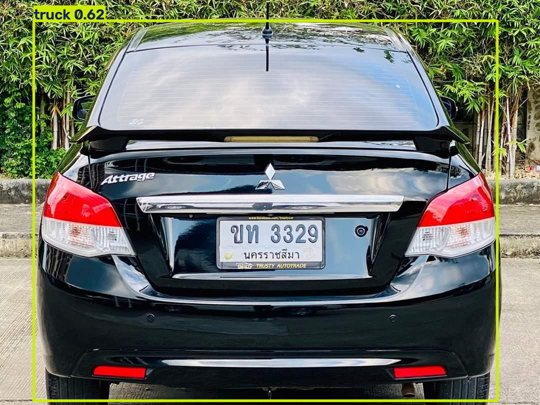

In [5]:
from IPython.display import display
display(Image.fromarray(results[10].plot()[:, :, ::-1]).resize((540, 405)))

In [6]:
import numpy as np
widths = []
for p in glob.glob(f'{ROOT}/gate/train/images/*'):
    for cx, cy, w, h in read_boxes(label_of(p)):
        widths.append(w)
widths = np.array(widths) * 100
print('ป้ายในชุดฝึก', len(widths), 'ใบ')
print('กว้างกลางๆ %.1f%% ของภาพ  เล็กสุด %.1f%%  ใหญ่สุด %.1f%%' % (np.median(widths), widths.min(), widths.max()))

ป้ายในชุดฝึก 141 ใบ
กว้างกลางๆ 14.3% ของภาพ  เล็กสุด 5.3%  ใหญ่สุด 25.4%


In [8]:
ft = YOLO('yolov8n.pt')
ft.train(data=gate_yaml, epochs=5, imgsz=640, batch=8, seed=0,
         project=f'{ROOT}/runs', name='finetune', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune, nbs=64, nms=None, opset=None, optimize=False, optimizer=aut

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a921d379d00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

รอบแรก 48  รอบสุดท้าย 94.0 (เทรนทั้งหมด 5 รอบ)


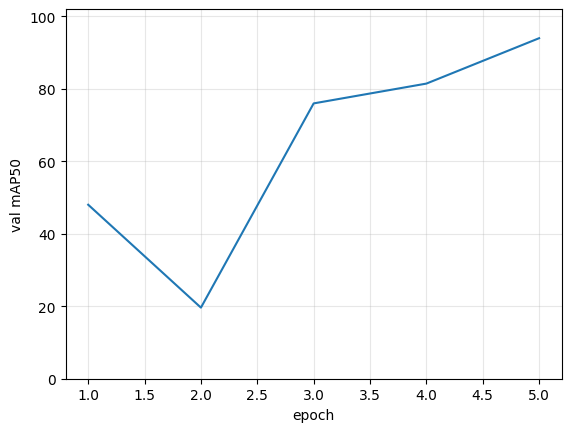

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

def curve(run):
    df = pd.read_csv(f'{ROOT}/runs/{run}/results.csv')
    df.columns = [c.strip() for c in df.columns]
    return df['metrics/mAP50(B)'].values * 100

m = curve('finetune')
if len(m) >= 7:
    print('รอบแรก %.0f  รอบที่ 7 %.0f  รอบสุดท้าย %.1f' % (m[0], m[6], m[-1]))
else:
    print('รอบแรก %.0f  รอบสุดท้าย %.1f (เทรนทั้งหมด %d รอบ)' % (m[0], m[-1], len(m)))
plt.plot(range(1, len(m)+1), m); plt.xlabel('epoch'); plt.ylabel('val mAP50'); plt.ylim(0, 102); plt.grid(alpha=.3); plt.show()

In [12]:
def score(weights, data, split='val'):
    r = YOLO(weights).val(data=data, split=split, imgsz=640, batch=8, plots=False, verbose=False)
    return r.box.map50 * 100, r.box.map * 100

ft_test = score(f'{ROOT}/runs/finetune/weights/best.pt', gate_yaml, 'test')
print('ชุดสอบ  mAP50 %.1f   mAP50-95 %.1f' % ft_test)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1718.9±388.6 MB/s, size: 152.1 KB)
val: Scanning /content/lpr/gate/test/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 200.9it/s 0.1s
val: New cache created: /content/lpr/gate/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 30. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.3s/it 9.2s
                   all         30         30          1      0.977      0.995      0.807
Speed: 2.7ms preprocess, 260.0ms inference, 0.0ms loss, 14.0ms postprocess per image

In [6]:
from ultralytics import YOLO
ROOT = '/content/lpr'
gate_yaml = f'{ROOT}/gate.yaml'
scratch = YOLO('yolov8n.yaml')                  # โครงสร้างเดียวกัน แต่น้ำหนักเริ่มจากค่าสุ่ม
scratch.train(data=gate_yaml, epochs=5, imgsz=640, batch=8, seed=0, pretrained=False,
              project=f'{ROOT}/runs', name='scratch', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=scratch, nbs=64, nms=None, opset=None, optimize=False, optimizer=au

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b24609a3650>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [8]:
frozen = YOLO('yolov8n.pt')
frozen.train(data=gate_yaml, epochs=5, imgsz=640, batch=8, seed=0, freeze=10,   # ล็อก 10 ชั้นแรก คือส่วนตา
             project=f'{ROOT}/runs', name='frozen', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=frozen, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b243efe88c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1221.7±227.9 MB/s, size: 152.1 KB)
val: Scanning /content/lpr/gate/test/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 5.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 30. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2s/it 4.8s
                   all         30         30          0          0          0          0
Speed: 1.9ms preprocess, 143.1ms inference, 0.0ms loss, 3.3ms postprocess per image
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu

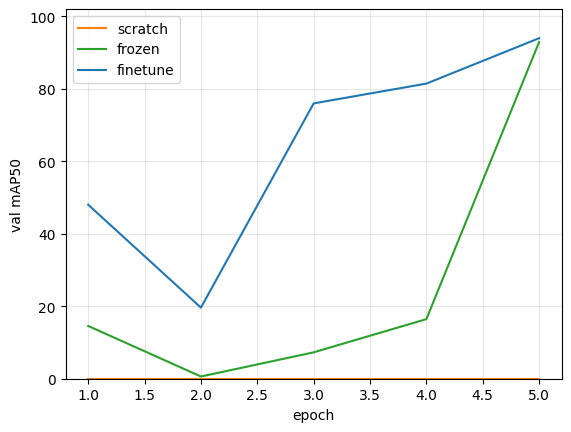

In [10]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

def score(weights, data, split='val'):
    r = YOLO(weights).val(data=data, split=split, imgsz=640, batch=8, plots=False, verbose=False)
    return r.box.map50 * 100, r.box.map * 100

def curve(run):
    df = pd.read_csv(f'{ROOT}/runs/{run}/results.csv')
    df.columns = [c.strip() for c in df.columns]
    return df['metrics/mAP50(B)'].values * 100

rows = []
for run, label in [('scratch', 'เริ่มจากศูนย์'), ('frozen', 'ยืมตาแล้วตรึง'), ('finetune', 'ยืมตาแล้วปรับทั้งตัว')]:
    m50, m5095 = score(f'{ROOT}/runs/{run}/weights/best.pt', gate_yaml, 'test')
    c = curve(run)
    stable = next((i + 1 for i in range(len(c)) if (c[i:] >= 94).all()), None)   # รอบแรกที่ยืนเหนือ 94 ได้ถาวร
    rows.append((label, c[0], '-' if stable is None else str(stable), m50, m5095))
print('%-22s %8s %12s %10s %10s' % ('วิธี', 'รอบแรก', 'ยืนเหนือ 94', 'mAP50', 'mAP50-95'))
for r in rows:
    print('%-22s %8.0f %12s %10.1f %10.1f' % r)
for run, c in [('scratch', 'tab:orange'), ('frozen', 'tab:green'), ('finetune', 'tab:blue')]:
    m = curve(run); plt.plot(range(1, len(m)+1), m, color=c, label=run)
plt.xlabel('epoch'); plt.ylabel('val mAP50'); plt.ylim(0, 102); plt.grid(alpha=.3); plt.legend(); plt.show()

In [14]:
import random, glob, os, shutil, yaml
from ultralytics import YOLO
ROOT = '/content/lpr'

def make_yaml(name, train, val, test=None):
    """เขียนไฟล์บอก YOLO ว่าชุดฝึก ชุดตรวจ ชุดสอบ อยู่โฟลเดอร์ไหน (ใช้ path เต็ม)"""
    d = {'path': ROOT, 'train': train, 'val': val, 'names': {0: 'plate'}}
    if test: d['test'] = test
    p = f'{ROOT}/{name}.yaml'
    yaml.safe_dump(d, open(p, 'w'))
    return p

def label_of(img_path):
    return img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

def link_subset(src_imgs, dst):
    """สร้างโฟลเดอร์ชุดข้อมูลใหม่จากรายชื่อภาพ โดยคัดลอกทั้งภาพและเฉลย"""
    os.makedirs(f'{dst}/images', exist_ok=True); os.makedirs(f'{dst}/labels', exist_ok=True)
    for p in src_imgs:
        shutil.copy(p, f'{dst}/images/'); shutil.copy(label_of(p), f'{dst}/labels/')
    return dst

random.seed(2569)
pick = random.sample(sorted(glob.glob(f'{ROOT}/gate/train/images/*')), 20)
link_subset(pick, f'{ROOT}/gate20/train')
gate20_yaml = make_yaml('gate20', 'gate20/train/images', 'gate/val/images', 'gate/test/images')
few = YOLO('yolov8n.pt')
few.train(data=gate20_yaml, epochs=5, imgsz=640, batch=8, seed=0,
          project=f'{ROOT}/runs', name='few20', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate20.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=few20, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b2434680b90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [16]:
ft_test = score(f'{ROOT}/runs/finetune/weights/best.pt', gate_yaml, 'test')
print('20 ใบ   ชุดสอบ mAP50 %.1f   mAP50-95 %.1f' % score(f'{ROOT}/runs/few20/weights/best.pt', gate_yaml, 'test'))
print('140 ใบ  ชุดสอบ mAP50 %.1f   mAP50-95 %.1f' % ft_test)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1654.0±332.6 MB/s, size: 140.2 KB)
val: Scanning /content/lpr/gate/test/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 5.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 30. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.7s/it 6.6s
                   all         30         30          1      0.977      0.995      0.807
Speed: 1.7ms preprocess, 188.9ms inference, 0.0ms loss, 10.5ms postprocess per image
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu 

In [17]:
road_yaml = make_yaml('road', 'road/images', 'road/images')
road_all = score(f'{ROOT}/runs/finetune/weights/best.pt', road_yaml)
print('หน้าลานจอด mAP50 %.1f   บนถนน mAP50 %.1f' % (ft_test[0], road_all[0]))

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1709.4±258.2 MB/s, size: 347.0 KB)
val: Scanning /content/lpr/road/labels... 139 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 1.9Kit/s 0.1s
val: New cache created: /content/lpr/road/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.1s/it 20.5s
                   all        139        416      0.833    0.00962      0.011    0.00556
Speed: 1.1ms preprocess, 120.1ms inference, 0.0ms loss, 6.8ms postprocess per image
หน้าลานจอด mAP50 99.5   บนถนน mAP50 1.1


In [20]:
from PIL import Image
import glob
import numpy as np
from ultralytics import YOLO

def read_boxes(label_path):
    """อ่านเฉลยหนึ่งไฟล์ คืนกรอบเป็น (cx, cy, w, h) สัดส่วนของภาพ รองรับทั้งกรอบและรูปหลายเหลี่ยม"""
    boxes = []
    for line in open(label_path):
        v = list(map(float, line.split()[1:]))
        if len(v) == 4:
            boxes.append(tuple(v))
        else:
            xs, ys = v[0::2], v[1::2]
            boxes.append(((min(xs)+max(xs))/2, (min(ys)+max(ys))/2, max(xs)-min(xs), max(ys)-min(ys)))
    return boxes

def label_of(img_path):
    return img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

def iou(a, b):
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0])); iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter)

model = YOLO(f'{ROOT}/runs/finetune/weights/best.pt')
found, missed = [], []
for p in sorted(glob.glob(f'{ROOT}/road/images/*')):
    W, H = Image.open(p).size
    dets = [[float(v) for v in b] for b in model.predict(p, imgsz=640, conf=0.25, verbose=False)[0].boxes.xyxy]
    for cx, cy, w, h in read_boxes(label_of(p)):
        g = [(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H]
        (found if any(iou(d, g) >= 0.5 for d in dets) else missed).append(w * 100)
print('ป้ายทั้งหมด', len(found)+len(missed), 'ใบ  หาเจอ', len(found), 'ใบ')
print('ความกว้างกลางๆ ของป้ายที่เจอ %.1f%%  ที่พลาด %.1f%%' % (np.median(found), np.median(missed)))
for lo, hi in [(0, 1), (1, 2), (2, 3), (3, 5), (5, 100)]:
    f = sum(lo <= x < hi for x in found); m = sum(lo <= x < hi for x in missed)
    print('ป้ายกว้าง %2d-%-3d%%  ทั้งหมด %3d  เจอ %2d' % (lo, hi, f+m, f))

ป้ายทั้งหมด 416 ใบ  หาเจอ 2 ใบ
ความกว้างกลางๆ ของป้ายที่เจอ 9.0%  ที่พลาด 2.3%
ป้ายกว้าง  0-1  %  ทั้งหมด  23  เจอ  0
ป้ายกว้าง  1-2  %  ทั้งหมด 149  เจอ  0
ป้ายกว้าง  2-3  %  ทั้งหมด  81  เจอ  0
ป้ายกว้าง  3-5  %  ทั้งหมด 102  เจอ  0
ป้ายกว้าง  5-100%  ทั้งหมด  61  เจอ  2


In [21]:
def iou(a, b):
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0])); iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter)

model = YOLO(f'{ROOT}/runs/finetune/weights/best.pt')
found, missed = [], []
for p in sorted(glob.glob(f'{ROOT}/road/images/*')):
    W, H = Image.open(p).size
    dets = [[float(v) for v in b] for b in model.predict(p, imgsz=640, conf=0.25, verbose=False)[0].boxes.xyxy]
    for cx, cy, w, h in read_boxes(label_of(p)):
        g = [(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H]
        (found if any(iou(d, g) >= 0.5 for d in dets) else missed).append(w * 100)
print('ป้ายทั้งหมด', len(found)+len(missed), 'ใบ  หาเจอ', len(found), 'ใบ')
print('ความกว้างกลางๆ ของป้ายที่เจอ %.1f%%  ที่พลาด %.1f%%' % (np.median(found), np.median(missed)))
for lo, hi in [(0, 1), (1, 2), (2, 3), (3, 5), (5, 100)]:
    f = sum(lo <= x < hi for x in found); m = sum(lo <= x < hi for x in missed)
    print('ป้ายกว้าง %2d-%-3d%%  ทั้งหมด %3d  เจอ %2d' % (lo, hi, f+m, f))

ป้ายทั้งหมด 416 ใบ  หาเจอ 2 ใบ
ความกว้างกลางๆ ของป้ายที่เจอ 9.0%  ที่พลาด 2.3%
ป้ายกว้าง  0-1  %  ทั้งหมด  23  เจอ  0
ป้ายกว้าง  1-2  %  ทั้งหมด 149  เจอ  0
ป้ายกว้าง  2-3  %  ทั้งหมด  81  เจอ  0
ป้ายกว้าง  3-5  %  ทั้งหมด 102  เจอ  0
ป้ายกว้าง  5-100%  ทั้งหมด  61  เจอ  2


In [24]:
import re

frame_no = lambda p: int(re.search(r'-(\d+)_jpg', p).group(1))
road_imgs = sorted(glob.glob(f'{ROOT}/road/images/*'), key=frame_no)
early = [p for p in road_imgs if frame_no(p) < 213]
late  = [p for p in road_imgs if frame_no(p) >= 213]
link_subset(early, f'{ROOT}/road_time/train'); link_subset(late, f'{ROOT}/road_time/val')
road_time_yaml = make_yaml('road_time', 'road_time/train/images', 'road_time/val/images')
print('ชุดฝึก', len(early), 'เฟรม (เฟรมที่ %d ถึง %d)' % (frame_no(early[0]), frame_no(early[-1])))
print('ชุดตรวจ', len(late), 'เฟรม (เฟรมที่ %d ถึง %d)' % (frame_no(late[0]), frame_no(late[-1])))
print('ก่อนปรับ  ชุดตรวจบนถนน mAP50 %.1f' % score(f'{ROOT}/runs/finetune/weights/best.pt', road_time_yaml)[0])

ชุดฝึก 95 เฟรม (เฟรมที่ 3 ถึง 211)
ชุดตรวจ 44 เฟรม (เฟรมที่ 213 ถึง 307)
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3120.3±648.8 MB/s, size: 351.4 KB)
val: Scanning /content/lpr/road_time/val/labels... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 1.9Kit/s 0.0s
val: New cache created: /content/lpr/road_time/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.1s/it 6.7s
                   all         44        121      0.796     0.0248      0.032     0.0154
Speed: 1.2ms preprocess, 127.6ms inference, 0.0ms loss, 6.7ms postprocess per image
ก่อนปรับ  ชุดตรวจบนถนน mAP50 3.2


In [25]:
adapt = YOLO(f'{ROOT}/runs/finetune/weights/best.pt')    # เริ่มจากสมองที่เก่งหน้าลานจอดแล้ว
adapt.train(data=road_time_yaml, epochs=12, imgsz=640, batch=8, seed=0,
            project=f'{ROOT}/runs', name='roadadapt', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/road_time.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=12, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/lpr/runs/finetune/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roadadapt, nbs=64, nms=None, op

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b2434520910>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [26]:
w = f'{ROOT}/runs/roadadapt/weights/best.pt'
print('หลังปรับ  ชุดตรวจบนถนน mAP50 %.1f' % score(w, road_time_yaml)[0])
print('หลังปรับ  ชุดสอบหน้าลานจอด mAP50 %.1f   (ก่อนปรับ %.1f)' % (score(w, gate_yaml, 'test')[0], ft_test[0]))

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1723.5±355.9 MB/s, size: 345.1 KB)
val: Scanning /content/lpr/road_time/val/labels.cache... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 6.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.5s/it 9.2s
                   all         44        121      0.638      0.495      0.507       0.19
Speed: 1.8ms preprocess, 169.0ms inference, 0.0ms loss, 14.3ms postprocess per image
หลังปรับ  ชุดตรวจบนถนน mAP50 50.7
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2469.7±586.5 MB/s, size: 181.2 KB)
val: Scanning /content/lpr/gate/tes

In [27]:
link_subset(glob.glob(f'{ROOT}/gate/train/images/*') + early, f'{ROOT}/mix/train')
mix_yaml = make_yaml('mix', 'mix/train/images', 'road_time/val/images')
mix = YOLO(f'{ROOT}/runs/finetune/weights/best.pt')
mix.train(data=mix_yaml, epochs=12, imgsz=640, batch=8, seed=0,
          project=f'{ROOT}/runs', name='mix', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/mix.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=12, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/lpr/runs/finetune/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mix, nbs=64, nms=None, opset=None, op

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b24373bc360>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [28]:
w = f'{ROOT}/runs/mix/weights/best.pt'
print('ซ้อมทวน  ชุดตรวจบนถนน mAP50 %.1f' % score(w, road_time_yaml)[0])
print('ซ้อมทวน  ชุดสอบหน้าลานจอด mAP50 %.1f' % score(w, gate_yaml, 'test')[0])

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2420.7±270.7 MB/s, size: 428.6 KB)
val: Scanning /content/lpr/road_time/val/labels.cache... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 10.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.1s/it 6.5s
                   all         44        121      0.734      0.587      0.608      0.236
Speed: 1.0ms preprocess, 121.3ms inference, 0.0ms loss, 6.8ms postprocess per image
ซ้อมทวน  ชุดตรวจบนถนน mAP50 60.8
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1183.5±346.4 MB/s, size: 157.9 KB)
val: Scanning /content/lpr/gate/test

In [30]:
hot = YOLO('yolov8n.pt')
hot.train(data=gate_yaml, epochs=15, imgsz=140, batch=8, seed=0,
          optimizer='SGD', lr0=0.1, warmup_epochs=0,        # ก้าวใหญ่ห้าสิบเท่า ไม่วอร์มอัพ
          project=f'{ROOT}/runs', name='hotlr', exist_ok=True, plots=False, verbose=False)
print('คะแนนชุดตรวจแต่ละรอบ', [round(x) for x in curve('hotlr')])
print('ชุดสอบหน้าลานจอด %.1f   บนถนน %.1f' % (score(f'{ROOT}/runs/hotlr/weights/best.pt', gate_yaml, 'test')[0],
                                             score(f'{ROOT}/runs/hotlr/weights/best.pt', road_yaml)[0]))

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=140, iou=0.7, kobj=1.0, line_width=None, lr0=0.1, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hotlr, nbs=64, nms=None, opset=None, optimize=False, optimizer=SGD, o